# CNN-Transformer v2 — Improved Architecture

Improvements over baseline:
1. **Attention pooling** — learns which frames matter most
2. **4 Transformer layers, 8 heads** — deeper temporal modelling
3. **Label smoothing** — reduces overconfidence, improves calibration
4. **Test-time augmentation (TTA)** — averages predictions over multiple noisy passes

Saves model as `model_cnntransformer_v2_improved.keras` so the baseline is preserved.

In [ ]:
!pip -q install datasets librosa numpy scikit-learn tensorflow pandas scipy matplotlib

In [ ]:
import os,glob,zipfile,requests,time
import numpy as np,pandas as pd,librosa,scipy.optimize
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import tensorflow as tf
from tensorflow.keras import layers,Model,mixed_precision
from sklearn.metrics import confusion_matrix,classification_report,roc_auc_score,roc_curve
from datasets import load_dataset
from google.colab import drive
drive.mount('/content/drive')

mixed_precision.set_global_policy('mixed_float16')
tf.config.optimizer.set_jit(True)
for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu,True)

SEED=42;rng=np.random.default_rng(SEED);tf.random.set_seed(SEED)
WIN_S=0.5;HOP_S=0.25;MAX_WINDOWS_PER_CLIP=10
SR_TARGET=16000;N_MELS=64;N_FFT=512;HOP_LENGTH=128;FMAX=8000;TOP_DB=80
TRAIN_FRAC=0.8;VAL_FRAC=0.1;TEST_FRAC=0.1
AUG_PROB=0.7;SNR_MIN=-5.0;SNR_MAX=20.0
FREQ_MASK_MAX=8;TIME_MASK_MAX=8
TIME_STRETCH_PROB=0.3;TIME_STRETCH_MIN=0.80;TIME_STRETCH_MAX=1.25

# Improved hyperparameters
D_MODEL=128;NUM_HEADS=8;FFN_DIM=256;NUM_TRANSFORMER_LAYERS=4
DROPOUT_RATE=0.30;LABEL_SMOOTHING=0.05;TTA_N_AUGMENTS=5
BATCH=64;EPOCHS=30;AUTOTUNE=tf.data.AUTOTUNE

OUT_DIR='/content/drive/MyDrive/drone_audio_processed'
os.makedirs(OUT_DIR,exist_ok=True)
OUT_PATH=os.path.join(OUT_DIR,'waveform_0.50s_hop0.25s_recordsplit.npz')
MODEL_PATH=os.path.join(OUT_DIR,'model_cnntransformer_v2_improved.keras')
FIG_DIR=os.path.join(OUT_DIR,'figures');os.makedirs(FIG_DIR,exist_ok=True)
DEMAND_DIR='/content/DEMAND'
DEMAND_ZENODO_BASE='https://zenodo.org/records/1227121/files'
DEMAND_16K_ENVS=['DKITCHEN','DLIVING','DWASHING','NFIELD','NPARK','NRIVER',
                  'OHALLWAY','OMEETING','OOFFICE','PCAFETER','PRESTO','PSTATION',
                  'SPSQUARE','STRAFFIC','TBUS','TCAR','TMETRO']
EXT_ROOT='/content/external_drone_thesis'
EXT_ZIP_URL='https://codeload.github.com/DroneDetectionThesis/Drone-detection-dataset/zip/refs/heads/master'
THRESHOLDS=np.round(np.arange(0.05,0.96,0.05),2)
CMAP=LinearSegmentedColormap.from_list('thesis_blue',['#FFFFFF','#2E74B5'],N=256)
plt.rcParams.update({'font.family':'DejaVu Sans','font.size':10})
print('Config loaded. TF:',tf.__version__)

Mounted at /content/drive
Config loaded. TF: 2.20.0


In [ ]:
def log_mel_db(y,sr):
    y=np.asarray(y,dtype=np.float32)
    mel=librosa.feature.melspectrogram(y=y,sr=sr,n_mels=N_MELS,n_fft=N_FFT,
                                        hop_length=HOP_LENGTH,fmax=FMAX,power=2.0)
    return librosa.power_to_db(mel,ref=1.0,top_db=TOP_DB).astype(np.float32)
def windows_all(y,sr,win_s,hop_s,rl):
    y=np.asarray(y,dtype=np.float32);win=int(round(win_s*sr));hop=int(round(hop_s*sr))
    if len(y)<=win:
        out=np.zeros(win,dtype=np.float32);s=rl.integers(0,win-len(y)+1);out[s:s+len(y)]=y;return [out]
    return [y[s:s+win] for s in range(0,len(y)-win+1,hop)]
def sample_windows(w,k,rl):
    if k is None or len(w)<=k: return w
    return [w[i] for i in rl.choice(len(w),size=k,replace=False)]
def stratified_recording_split(indices,labels,train_frac,val_frac,test_frac,rl):
    idx0=indices[labels[indices]==0];idx1=indices[labels[indices]==1]
    rl.shuffle(idx0);rl.shuffle(idx1)
    def split(arr):
        n=len(arr);a=int(round(train_frac*n));b=int(round(val_frac*n))
        return arr[:a],arr[a:a+b],arr[a+b:]
    tr0,va0,te0=split(idx0);tr1,va1,te1=split(idx1)
    train=np.concatenate([tr0,tr1]);rl.shuffle(train)
    val=np.concatenate([va0,va1]);rl.shuffle(val)
    test=np.concatenate([te0,te1]);rl.shuffle(test)
    return train,val,test
def build_wave_windows(ds,rec_indices,rl):
    subset=ds.select(rec_indices.tolist());X_wav,y_out=[],[]
    for i,s in enumerate(subset):
        if i%5000==0: print(f'  {i}/{len(rec_indices)}')
        label=int(s['label']);y=np.asarray(s['audio']['array'],dtype=np.float32)
        sr=int(s['audio']['sampling_rate'])
        if sr!=SR_TARGET: y=librosa.resample(y,orig_sr=sr,target_sr=SR_TARGET)
        wins=sample_windows(windows_all(y,SR_TARGET,WIN_S,HOP_S,rl),MAX_WINDOWS_PER_CLIP,rl)
        for w in wins: X_wav.append(w);y_out.append(label)
    return np.stack(X_wav).astype(np.float32),np.array(y_out,dtype=np.float32)
def balance_downsample(X,y,rl):
    idx0=np.where(y==0)[0];idx1=np.where(y==1)[0];n_min=min(len(idx0),len(idx1))
    keep=np.concatenate([rl.choice(idx0,n_min,replace=False),rl.choice(idx1,n_min,replace=False)])
    rl.shuffle(keep);return X[keep],y[keep]
def mel_to_model_array(mel):
    mel=mel[...,None].astype(np.float32);return ((mel-np.mean(mel))/(np.std(mel)+1e-6)).astype(np.float32)
def rms(x): return np.sqrt(np.mean(np.asarray(x,dtype=np.float32)**2)+1e-12)
def add_real_noise_snr(y,nb_bank,snr_db,rl):
    y=np.asarray(y,dtype=np.float32);nb=nb_bank[rl.integers(0,len(nb_bank))];n=len(y)
    if len(nb)>=n: s=rl.integers(0,len(nb)-n+1);nb=nb[s:s+n]
    else: nb=np.tile(nb,int(np.ceil(n/len(nb))))[:n]
    noise_scaled=nb*(rms(y)/(10**(snr_db/20.0))/(rms(nb)+1e-12))
    y_noisy=y+noise_scaled;peak=np.max(np.abs(y_noisy))
    return (y_noisy/peak).astype(np.float32) if peak>1.0 else y_noisy
def drone_metrics(y_true,y_prob,t):
    pred=(y_prob>=t).astype(int);cm=confusion_matrix(y_true,pred,labels=[0,1])
    tp=cm[1,1];fp=cm[0,1];fn=cm[1,0];prec=tp/(tp+fp+1e-9);rec=tp/(tp+fn+1e-9)
    return prec,rec,2*prec*rec/(prec+rec+1e-9)
def plot_cm(cm,title,ax):
    thresh=cm.max()/2.0;im=ax.imshow(cm,cmap=CMAP,vmin=0,vmax=cm.max(),interpolation='nearest')
    plt.colorbar(im,ax=ax,fraction=0.046,pad=0.06).set_label('Count',fontsize=8)
    ax.set_xticks([0,1]);ax.set_yticks([0,1])
    ax.set_xticklabels(['No Drone','Drone'],fontsize=9);ax.set_yticklabels(['No Drone','Drone'],fontsize=9)
    ax.set_xlabel('Predicted',fontsize=9,labelpad=8);ax.set_ylabel('Actual',fontsize=9,labelpad=18)
    ax.set_title(title,fontsize=9,fontweight='normal',pad=10)
    for row in range(2):
        rt=cm[row].sum()
        for col in range(2):
            count=cm[row,col];pct=count/rt*100 if rt>0 else 0
            color='white' if count>thresh else '#1a1a1a'
            ax.text(col,row-0.12,[['TN','FP'],['FN','TP']][row][col],ha='center',va='center',fontsize=11,fontweight='bold',color=color)
            ax.text(col,row+0.12,f'{count:,}\n({pct:.1f}%)',ha='center',va='center',fontsize=9,color=color)
def save_fig(fig,name):
    path=os.path.join(FIG_DIR,name);fig.savefig(path,dpi=200,bbox_inches='tight',facecolor='white');print(f'Saved: {path}')
print('Helpers defined.')

Helpers defined.


In [ ]:
print('Loading dataset...')
ds=load_dataset('geronimobasso/drone-audio-detection-samples',split='train')
labels=np.array(ds['label'],dtype=np.int64);sr_used=SR_TARGET
_tmp=np.zeros(int(round(WIN_S*sr_used)),dtype=np.float32)
N_FRAMES=log_mel_db(_tmp,sr_used).shape[1];INPUT_SHAPE=(N_MELS,N_FRAMES,1)
print(f'Input shape: {INPUT_SHAPE}')

Loading dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/39 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/39 [00:00<?, ?it/s]

...

data/train-00036-of-00039.parquet:   0%|          | 0.00/75.0M [00:00<?, ?B/s]

data/train-00037-of-00039.parquet:   0%|          | 0.00/74.9M [00:00<?, ?B/s]

data/train-00038-of-00039.parquet:   0%|          | 0.00/75.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/180320 [00:00<?, ? examples/s]

Input shape: (64, 63, 1)


In [ ]:
if not os.path.exists(DEMAND_DIR) or not glob.glob(os.path.join(DEMAND_DIR,'**','*.wav'),recursive=True):
    os.makedirs(DEMAND_DIR,exist_ok=True)
    for env in DEMAND_16K_ENVS:
        url=f'{DEMAND_ZENODO_BASE}/{env}_16k.zip?download=1'
        zip_path=f'/content/demand_{env.lower()}.zip'
        print(f'  {env}...',end=' ',flush=True)
        for attempt in range(3):
            try: r=requests.get(url,stream=True,timeout=120);r.raise_for_status();break
            except: time.sleep(5)
        with open(zip_path,'wb') as f:
            for chunk in r.iter_content(1024*1024): f.write(chunk)
        with zipfile.ZipFile(zip_path) as z: z.extractall(DEMAND_DIR)
        os.remove(zip_path);print('done')
noise_bank=[];seg_n=int(3.0*sr_used)
for p in glob.glob(os.path.join(DEMAND_DIR,'**','*.wav'),recursive=True):
    try:
        y,fs=librosa.load(p,sr=None,mono=True)
        if fs!=sr_used: y=librosa.resample(y,orig_sr=fs,target_sr=sr_used)
        for s in range(0,len(y)-seg_n+1,seg_n):
            seg=y[s:s+seg_n].astype(np.float32)
            if np.max(np.abs(seg))>1e-4: noise_bank.append(seg)
    except: pass
print(f'Noise bank: {len(noise_bank)} segments')

  DKITCHEN... done
  DLIVING... done
  DWASHING... done
  NFIELD... done
  NPARK... done
  NRIVER... done
  OHALLWAY... done
  OMEETING... done
  OOFFICE... done
  PCAFETER... done
  PRESTO... done
  PSTATION... done
  SPSQUARE... done
  STRAFFIC... done
  TBUS... done
  TCAR... done
  TMETRO... done
Noise bank: 27200 segments


In [ ]:
all_idx=np.arange(len(ds),dtype=np.int64)
train_rec,val_rec,test_rec=stratified_recording_split(all_idx,labels,TRAIN_FRAC,VAL_FRAC,TEST_FRAC,rng)
if os.path.exists(OUT_PATH):
    print(f'Loading cached NPZ: {OUT_PATH}')
    _c=np.load(OUT_PATH)
    X_train_wav=_c['X_train_wav'];y_train_wav=_c['y_train_wav']
    X_val_wav=_c['X_val_wav'];y_val_wav=_c['y_val_wav']
    X_test_wav=_c['X_test_wav'];y_test_wav=_c['y_test_wav']
    print(f'  train={X_train_wav.shape}, val={X_val_wav.shape}, test={X_test_wav.shape}')
else:
    print('Extracting windows...')
    X_train_wav,y_train_wav=build_wave_windows(ds,train_rec,rng)
    X_val_wav,y_val_wav=build_wave_windows(ds,val_rec,rng)
    X_test_wav,y_test_wav=build_wave_windows(ds,test_rec,rng)
    X_train_wav,y_train_wav=balance_downsample(X_train_wav,y_train_wav,rng)
    np.savez_compressed(OUT_PATH,X_train_wav=X_train_wav,y_train_wav=y_train_wav,
        X_val_wav=X_val_wav,y_val_wav=y_val_wav,X_test_wav=X_test_wav,y_test_wav=y_test_wav,
        sr=sr_used,win_s=WIN_S,hop_s=HOP_S)
    print(f'Cached: {OUT_PATH}')

Loading cached NPZ: /content/drive/MyDrive/drone_audio_processed/waveform_0.50s_hop0.25s_recordsplit.npz
  train=(255488, 8000), val=(32731, 8000), test=(32694, 8000)


In [ ]:
def tf_logmel_from_wave(wave):
    def _py(w): return log_mel_db(w.numpy().astype(np.float32),sr_used)
    mel=tf.py_function(_py,inp=[wave],Tout=tf.float32);mel.set_shape([N_MELS,N_FRAMES]);return mel
def augment_wave_with_noise(wave,label):
    def add_noise():
        snr=tf.random.uniform([],SNR_MIN,SNR_MAX,dtype=tf.float32)
        def _py(w,snr_db):
            return add_real_noise_snr(w.numpy().astype(np.float32),noise_bank,float(snr_db),np.random.default_rng()).astype(np.float32)
        w_n=tf.py_function(_py,inp=[wave,snr],Tout=tf.float32);w_n.set_shape(wave.shape);return w_n,label
    return tf.cond(tf.random.uniform([])<AUG_PROB,add_noise,lambda:(wave,label))
def augment_time_stretch(wave,label):
    def do_stretch():
        rate=tf.random.uniform([],TIME_STRETCH_MIN,TIME_STRETCH_MAX)
        def _py(w,r):
            w=w.numpy().astype(np.float32);win=int(WIN_S*sr_used)
            s=librosa.effects.time_stretch(w,rate=float(r))
            if len(s)>=win: s=s[(len(s)-win)//2:(len(s)-win)//2+win]
            else: s=np.pad(s,(0,win-len(s)))
            return s.astype(np.float32)
        w_s=tf.py_function(_py,inp=[wave,rate],Tout=tf.float32);w_s.set_shape(wave.shape);return w_s,label
    return tf.cond(tf.random.uniform([])<TIME_STRETCH_PROB,do_stretch,lambda:(wave,label))
def apply_spec_augment(mel):
    f=tf.random.uniform([],0,FREQ_MASK_MAX+1,dtype=tf.int32)
    f0=tf.random.uniform([],0,tf.maximum(1,N_MELS-f+1),dtype=tf.int32)
    mask_f=tf.concat([tf.ones((f0,N_FRAMES,1),mel.dtype),tf.zeros((f,N_FRAMES,1),mel.dtype),
                       tf.ones((N_MELS-f0-f,N_FRAMES,1),mel.dtype)],axis=0);mel=mel*mask_f
    t=tf.random.uniform([],0,TIME_MASK_MAX+1,dtype=tf.int32)
    t0=tf.random.uniform([],0,tf.maximum(1,N_FRAMES-t+1),dtype=tf.int32)
    mask_t=tf.concat([tf.ones((N_MELS,t0,1),mel.dtype),tf.zeros((N_MELS,t,1),mel.dtype),
                       tf.ones((N_MELS,N_FRAMES-t0-t,1),mel.dtype)],axis=1);return mel*mask_t
def normalise_mel(mel):
    return (mel-tf.reduce_mean(mel))/(tf.math.reduce_std(mel)+1e-6)
def wave_to_model_input_train(wave,label):
    wave,label=augment_time_stretch(wave,label);wave,label=augment_wave_with_noise(wave,label)
    mel=tf_logmel_from_wave(wave);mel=mel[...,tf.newaxis];mel=apply_spec_augment(mel);mel=normalise_mel(mel)
    return tf.cast(mel,tf.float32),tf.cast(label,tf.float32)
def wave_to_model_input_eval(wave,label):
    wave,label=augment_wave_with_noise(wave,label)
    mel=tf_logmel_from_wave(wave);mel=mel[...,tf.newaxis];mel=normalise_mel(mel)
    return tf.cast(mel,tf.float32),tf.cast(label,tf.float32)
train_ds=(tf.data.Dataset.from_tensor_slices((X_train_wav,y_train_wav)).shuffle(len(X_train_wav),seed=SEED)
          .map(wave_to_model_input_train,num_parallel_calls=AUTOTUNE).batch(BATCH).prefetch(AUTOTUNE))
val_ds=(tf.data.Dataset.from_tensor_slices((X_val_wav,y_val_wav))
        .map(wave_to_model_input_eval,num_parallel_calls=AUTOTUNE).batch(BATCH).prefetch(AUTOTUNE))
test_ds=(tf.data.Dataset.from_tensor_slices((X_test_wav,y_test_wav))
         .map(wave_to_model_input_eval,num_parallel_calls=AUTOTUNE).batch(BATCH).prefetch(AUTOTUNE))
print('tf.data pipelines ready.')

tf.data pipelines ready.


In [ ]:
# Improved CNN-Transformer v2 with attention pooling
class AttentionPooling(layers.Layer):
    """Learned attention pooling over time — replaces GlobalAveragePooling1D.
    Assigns a learned importance weight to each time frame before pooling."""
    def __init__(self,d_model,**kwargs):
        super().__init__(**kwargs)
        self.attn_vec=layers.Dense(d_model,use_bias=True,activation='tanh')
        self.attn_score=layers.Dense(1,use_bias=False)
    def call(self,x,training=False):
        scores=self.attn_score(self.attn_vec(x))   # (batch,time,1)
        weights=tf.nn.softmax(scores,axis=1)         # (batch,time,1)
        return tf.reduce_sum(x*weights,axis=1)       # (batch,d_model)
    def get_config(self): return super().get_config()

def cnn_transformer_v2(input_shape,d_model=D_MODEL,num_heads=NUM_HEADS,
                        ffn_dim=FFN_DIM,num_layers=NUM_TRANSFORMER_LAYERS,dropout_rate=DROPOUT_RATE):
    inp=layers.Input(shape=input_shape,name='input_mel')
    # CNN encoder
    x=layers.Conv2D(64,3,padding='same',use_bias=False,kernel_initializer='he_normal',name='stem_conv')(inp)
    x=layers.BatchNormalization(name='stem_bn')(x);x=layers.ReLU(name='stem_relu')(x)
    x=layers.MaxPooling2D((2,2),padding='same',name='stem_pool')(x)
    x=layers.DepthwiseConv2D(3,padding='same',use_bias=False,depthwise_initializer='he_normal',name='b1_dw')(x)
    x=layers.BatchNormalization(name='b1_dw_bn')(x);x=layers.ReLU(name='b1_dw_relu')(x)
    x=layers.Conv2D(128,1,use_bias=False,kernel_initializer='he_normal',name='b1_pw')(x)
    x=layers.BatchNormalization(name='b1_pw_bn')(x);x=layers.ReLU(name='b1_pw_relu')(x)
    x=layers.MaxPooling2D((2,1),padding='same',name='b1_pool')(x)
    x=layers.DepthwiseConv2D(3,padding='same',use_bias=False,depthwise_initializer='he_normal',name='b2_dw')(x)
    x=layers.BatchNormalization(name='b2_dw_bn')(x);x=layers.ReLU(name='b2_dw_relu')(x)
    x=layers.Conv2D(d_model,1,use_bias=False,kernel_initializer='he_normal',name='b2_pw')(x)
    x=layers.BatchNormalization(name='b2_pw_bn')(x);x=layers.ReLU(name='b2_pw_relu')(x)
    # Frequency pooling
    freq_dim=x.shape[1]
    x=layers.Permute((2,1,3),name='perm_time_first')(x)
    x=layers.Reshape((-1,freq_dim*d_model),name='reshape_flat')(x)
    x=layers.Dense(d_model,use_bias=False,name='freq_proj')(x)
    # Positional encoding
    pos=layers.Conv1D(d_model,3,padding='same',use_bias=True,name='pos_enc_conv')(x)
    x=layers.Add(name='pos_add')([x,pos]);x=layers.Dropout(dropout_rate,name='pos_dropout')(x)
    # Transformer encoder — 4 layers, 8 heads
    for i in range(num_layers):
        xn=layers.LayerNormalization(name=f'ln1_{i}')(x)
        at=layers.MultiHeadAttention(num_heads=num_heads,key_dim=d_model//num_heads,
                                      dropout=dropout_rate,name=f'mha_{i}')(xn,xn)
        x=layers.Add(name=f'attn_add_{i}')([x,at]);x=layers.Dropout(dropout_rate,name=f'attn_drop_{i}')(x)
        xn=layers.LayerNormalization(name=f'ln2_{i}')(x)
        ff=layers.Dense(ffn_dim,activation='relu',name=f'ffn1_{i}')(xn)
        ff=layers.Dropout(dropout_rate,name=f'ffn_drop_{i}')(ff)
        ff=layers.Dense(d_model,name=f'ffn2_{i}')(ff)
        x=layers.Add(name=f'ffn_add_{i}')([x,ff])
    x=layers.LayerNormalization(name='final_ln')(x)
    # Attention pooling (improvement over GlobalAveragePooling1D)
    x=AttentionPooling(d_model,name='attn_pool')(x)
    x=layers.Dropout(dropout_rate,name='head_drop1')(x)
    x=layers.Dense(64,activation='relu',dtype='float32',name='head_fc')(x)
    x=layers.Dropout(dropout_rate,name='head_drop2')(x)
    logits=layers.Dense(1,activation=None,dtype='float32',name='logits')(x)
    return Model(inp,logits,name='cnn_transformer_v2')

N_FRAMES=int(np.ceil(WIN_S*SR_TARGET/HOP_LENGTH));INPUT_SHAPE=(N_MELS,N_FRAMES,1)
model=cnn_transformer_v2(INPUT_SHAPE)
model.summary()
print(f'\nParameters: {model.count_params():,}')

Model: "cnn_transformer_v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_mel           │ (None, 64, 63, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 64, 63,    │        576 │ input_mel[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 64, 63,    │        256 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_relu (ReLU)    │ (None, 64, 63,    │          0 │ stem_bn[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_pool           │ (None, 32, 32,    │          0 │ stem_relu[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b1_dw               │ (None, 32, 32,    │        576 │ stem_pool[0][0]   │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b1_dw_bn            │ (None, 32, 32,    │        256 │ b1_dw[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b1_dw_relu (ReLU)   │ (None, 32, 32,    │          0 │ b1_dw_bn[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b1_pw (Conv2D)      │ (None, 32, 32,    │      8,192 │ b1_dw_relu[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b1_pw_bn            │ (None, 32, 32,    │        512 │ b1_pw[0][0]       │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b1_pw_relu (ReLU)   │ (None, 32, 32,    │          0 │ b1_pw_bn[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b1_pool             │ (None, 16, 32,    │          0 │ b1_pw_relu[0][0]  │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b2_dw               │ (None, 16, 32,    │      1,152 │ b1_pool[0][0]     │
│ (DepthwiseConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b2_dw_bn            │ (None, 16, 32,    │        512 │ b2_dw[0][0]       │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b2_dw_relu (ReLU)   │ (None, 16, 32,    │          0 │ b2_dw_bn[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b2_pw (Conv2D)      │ (None, 16, 32,    │     16,384 │ b2_dw_relu[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b2_pw_bn            │ (None, 16, 32,    │        512 │ b2_pw[0][0]     

 Total params: 895,489 (3.42 MB)

 Trainable params: 894,465 (3.41 MB)

 Non-trainable params: 1,024 (4.00 KB)


Parameters: 895,489


In [ ]:
# Compile with label smoothing and train
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True,label_smoothing=LABEL_SMOOTHING),
    metrics=[tf.keras.metrics.BinaryAccuracy(name='accuracy',threshold=0.0),
             tf.keras.metrics.AUC(name='auc',from_logits=True),
             tf.keras.metrics.Precision(name='precision',thresholds=0.0),
             tf.keras.metrics.Recall(name='recall',thresholds=0.0)]
)
callbacks=[
    tf.keras.callbacks.ModelCheckpoint(MODEL_PATH,monitor='val_auc',mode='max',save_best_only=True,verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_auc',mode='max',patience=6,restore_best_weights=True,verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_auc',mode='max',factor=0.5,patience=3,min_lr=1e-6,verbose=1),
]
history=model.fit(train_ds,validation_data=val_ds,epochs=EPOCHS,callbacks=callbacks,verbose=1)

Epoch 1/30
3992/3992 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - accuracy: 0.9641 - auc: 0.9848 - loss: 0.2002 - precision: 0.9724 - recall: 0.9549
Epoch 1: val_auc improved from None to 0.99607, saving model to /content/drive/MyDrive/drone_audio_processed/model_cnntransformer_v2_improved.keras

Epoch 1: finished saving model to /content/drive/MyDrive/drone_audio_processed/model_cnntransformer_v2_improved.keras
3992/3992 ━━━━━━━━━━━━━━━━━━━━ 1875s 449ms/step - accuracy: 0.9799 - auc: 0.9921 - loss: 0.1718 - precision: 0.9892 - recall: 0.9705 - val_accuracy: 0.9893 - val_auc: 0.9961 - val_loss: 0.2034 - val_precision: 0.9931 - val_recall: 0.9859 - learning_rate: 1.0000e-04
Epoch 2/30
3992/3992 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step - accuracy: 0.9860 - auc: 0.9951 - loss: 0.1561 - precision: 0.9951 - recall: 0.9768
Epoch 2: val_auc improved from 0.99607 to 0.99712, saving model to /content/drive/MyDrive/drone_audio_processed/model_cnntransformer_v2_improved.keras

Epoch 2: finished saving model to

Saved: /content/drive/MyDrive/drone_audio_processed/figures/cnntf_v2_training_curves.png


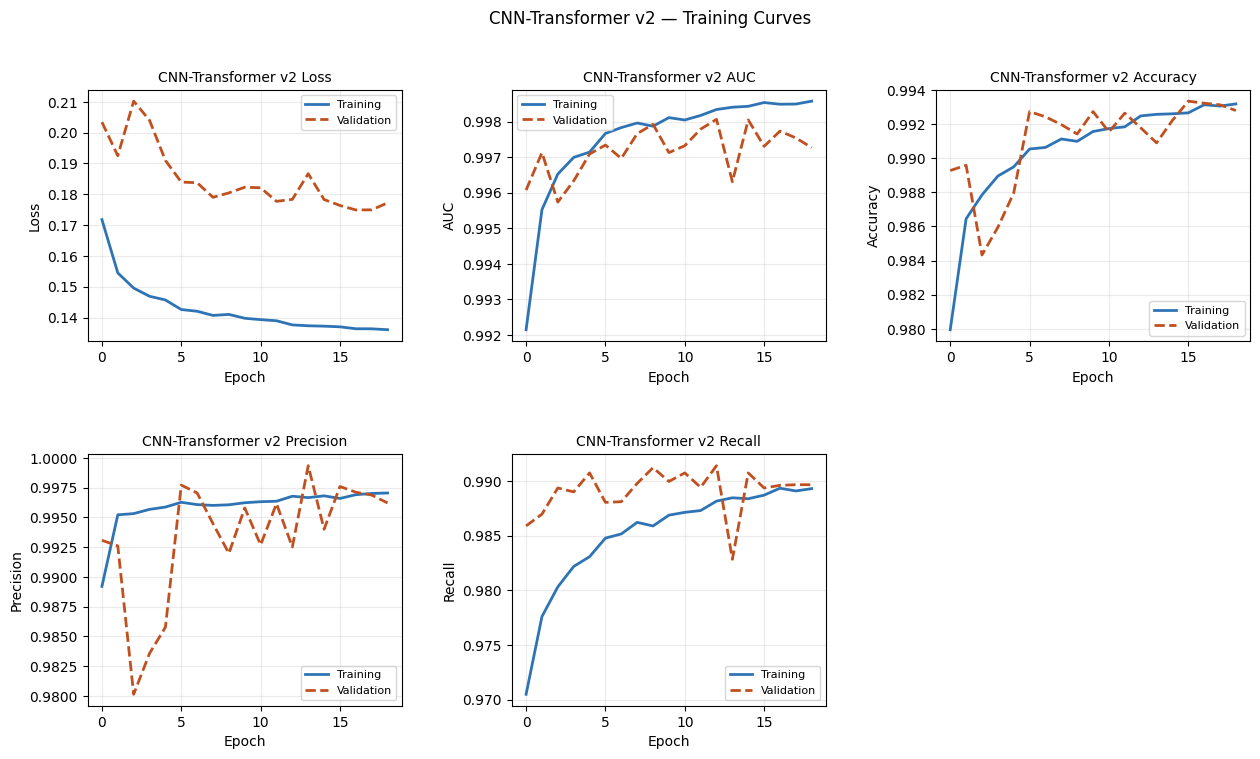

In [ ]:
h=history.history
fig,axes=plt.subplots(2,3,figsize=(15,8));fig.subplots_adjust(hspace=0.45,wspace=0.35)
for ax,(m,title) in zip(axes.flat,[('loss','Loss'),('auc','AUC'),('accuracy','Accuracy'),('precision','Precision'),('recall','Recall')]):
    ax.plot(h[m],color='#2E74B5',lw=2,label='Training')
    ax.plot(h[f'val_{m}'],color='#C05020',lw=2,ls='--',label='Validation')
    ax.set_title(f'CNN-Transformer v2 {title}',fontsize=10)
    ax.set_xlabel('Epoch');ax.set_ylabel(title);ax.legend(fontsize=8);ax.grid(alpha=0.25)
axes.flat[-1].set_visible(False)
fig.suptitle('CNN-Transformer v2 — Training Curves',fontsize=12)
save_fig(fig,'cnntf_v2_training_curves.png');plt.show()

In [ ]:
n_params=model.count_params();model_size=os.path.getsize(MODEL_PATH)/(1024*1024)
dummy=np.random.randn(1,N_MELS,N_FRAMES,1).astype(np.float32)
_=model.predict(dummy,verbose=0)
t0=time.time()
for _ in range(100): model.predict(dummy,verbose=0)
ms_v2=(time.time()-t0)/100*1000
print(f'Parameters: {n_params:,} | Size: {model_size:.2f} MB | Inference: {ms_v2:.2f} ms/window')

Parameters: 895,489 | Size: 17.47 MB | Inference: 74.48 ms/window


In [ ]:
# Internal evaluation
y_true_eval=np.concatenate([y.numpy() for x,y in test_ds],axis=0).astype(int)
y_logits=model.predict(test_ds,verbose=1).ravel()
y_prob=tf.sigmoid(y_logits).numpy()
int_auc=roc_auc_score(y_true_eval,y_prob)
print(f'Internal AUC: {int_auc:.4f}')
for t_thresh,label in [(0.5,'t=0.5'),(0.05,'t=0.05')]:
    pred=(y_prob>=t_thresh).astype(int)
    print(f'\n=== INTERNAL ({label}) ===')
    print(confusion_matrix(y_true_eval,pred))
    print(classification_report(y_true_eval,pred,digits=4))

511/511 ━━━━━━━━━━━━━━━━━━━━ 131s 246ms/step
Internal AUC: 0.9964

=== INTERNAL (t=0.5) ===
[[15693   120]
 [  272 16609]]
              precision    recall  f1-score   support

           0     0.9830    0.9924    0.9877     15813
           1     0.9928    0.9839    0.9883     16881

    accuracy                         0.9880     32694
   macro avg     0.9879    0.9881    0.9880     32694
weighted avg     0.9881    0.9880    0.9880     32694


=== INTERNAL (t=0.05) ===
[[15371   442]
 [  216 16665]]
              precision    recall  f1-score   support

           0     0.9861    0.9720    0.9790     15813
           1     0.9742    0.9872    0.9806     16881

    accuracy                         0.9799     32694
   macro avg     0.9802    0.9796    0.9798     32694
weighted avg     0.9800    0.9799    0.9799     32694



In [ ]:
# Temperature scaling
y_val_true=np.concatenate([y.numpy() for x,y in val_ds],axis=0).astype(int)
val_logits=model.predict(val_ds,verbose=0).ravel()
def nll_loss(log_T):
    T=np.exp(log_T[0]);probs=1/(1+np.exp(-val_logits/T));eps=1e-7
    return -np.mean(y_val_true*np.log(probs+eps)+(1-y_val_true)*np.log(1-probs+eps))
result=scipy.optimize.minimize(nll_loss,x0=[0.0],method='L-BFGS-B')
TEMPERATURE=float(np.exp(result.x[0]))
y_prob_cal=tf.sigmoid(y_logits/TEMPERATURE).numpy()
print(f'Temperature T = {TEMPERATURE:.4f}')
print(f'Internal AUC (uncal): {int_auc:.4f}  |  (cal): {roc_auc_score(y_true_eval,y_prob_cal):.4f}')

Temperature T = 1.0478
Internal AUC (uncal): 0.9964  |  (cal): 0.9964


In [ ]:
# External evaluation with TTA
os.makedirs(EXT_ROOT,exist_ok=True)
EXT_ZIP_PATH=os.path.join(EXT_ROOT,'repo.zip');EXT_EXTRACT_DIR=os.path.join(EXT_ROOT,'repo')
if not os.path.exists(EXT_ZIP_PATH):
    print('Downloading Svanström...')
    r=requests.get(EXT_ZIP_URL,stream=True);r.raise_for_status()
    with open(EXT_ZIP_PATH,'wb') as f:
        for chunk in r.iter_content(1024*1024): f.write(chunk)
    with zipfile.ZipFile(EXT_ZIP_PATH) as z: z.extractall(EXT_EXTRACT_DIR)
subdirs=[p for p in glob.glob(os.path.join(EXT_EXTRACT_DIR,'*')) if os.path.isdir(p)]
ext_wavs=sorted(glob.glob(os.path.join(subdirs[0],'**','*.wav'),recursive=True))
ext_labels=np.array([1 if 'drone' in os.path.basename(p).lower() else 0 for p in ext_wavs])
print(f'External: {len(ext_wavs)} clips — drone:{ext_labels.sum()}, no-drone:{(ext_labels==0).sum()}')

local_rng=np.random.default_rng(SEED)
ext_probs_std=[];ext_probs_tta=[]
print(f'Running external evaluation (standard + TTA n={TTA_N_AUGMENTS})...')
for p in ext_wavs:
    y,sr=librosa.load(p,sr=None,mono=True)
    if sr!=sr_used: y=librosa.resample(y,orig_sr=sr,target_sr=sr_used)
    wins=windows_all(y,sr_used,WIN_S,HOP_S,local_rng)
    if not wins: ext_probs_std.append(0.0);ext_probs_tta.append(0.0);continue
    # Standard
    X_std=[]
    for w in wins:
        if local_rng.random()<AUG_PROB: w=add_real_noise_snr(w,noise_bank,local_rng.uniform(SNR_MIN,SNR_MAX),local_rng)
        X_std.append(mel_to_model_array(log_mel_db(w,sr_used)))
    logits_std=model.predict(np.stack(X_std),batch_size=BATCH,verbose=0).ravel()
    ext_probs_std.append(float(np.max(tf.sigmoid(logits_std).numpy())))
    # TTA
    all_logits=[]
    for _ in range(TTA_N_AUGMENTS):
        X_tta=[mel_to_model_array(log_mel_db(add_real_noise_snr(w,noise_bank,local_rng.uniform(SNR_MIN,SNR_MAX),local_rng),sr_used)) for w in wins]
        all_logits.append(model.predict(np.stack(X_tta),batch_size=BATCH,verbose=0).ravel())
    ext_probs_tta.append(float(np.max(tf.sigmoid(np.mean(all_logits,axis=0)).numpy())))

ext_probs_std=np.array(ext_probs_std);ext_probs_tta=np.array(ext_probs_tta)
eps=1e-6
for name,probs in [('Standard',ext_probs_std),(f'TTA (n={TTA_N_AUGMENTS})',ext_probs_tta)]:
    auc=roc_auc_score(ext_labels,probs)
    print(f'\n=== {name} | External AUC: {auc:.4f} ===')
    for t_thresh in [0.5,0.05]:
        pred=(probs>=t_thresh).astype(int)
        print(f'--- t={t_thresh} ---')
        print(confusion_matrix(ext_labels,pred))
        print(classification_report(ext_labels,pred,digits=4))

External: 90 clips — drone:30, no-drone:60
Running external evaluation (standard + TTA n=5)...

=== Standard | External AUC: 0.4444 ===
--- t=0.5 ---
[[16 44]
 [ 9 21]]
              precision    recall  f1-score   support

           0     0.6400    0.2667    0.3765        60
           1     0.3231    0.7000    0.4421        30

    accuracy                         0.4111        90
   macro avg     0.4815    0.4833    0.4093        90
weighted avg     0.5344    0.4111    0.3983        90

--- t=0.05 ---
[[ 6 54]
 [ 2 28]]
              precision    recall  f1-score   support

           0     0.7500    0.1000    0.1765        60
           1     0.3415    0.9333    0.5000        30

    accuracy                         0.3778        90
   macro avg     0.5457    0.5167    0.3382        90
weighted avg     0.6138    0.3778    0.2843        90


=== TTA (n=5) | External AUC: 0.4344 ===
--- t=0.5 ---
[[21 39]
 [13 17]]
              precision    recall  f1-score   support

           0 

In [ ]:
# Threshold sweep — standard vs TTA
def run_sweep(ip,ep,label):
    rows=[]
    for t in THRESHOLDS:
        _,_,if1=drone_metrics(y_true_eval,ip,t)
        _,er,ef1=drone_metrics(ext_labels,ep,t)
        combined=2*if1*er/(if1+er+1e-9)
        rows.append(dict(threshold=t,int_f1=round(if1,4),ext_recall=round(er,4),ext_f1=round(ef1,4),combined=round(combined,4)))
    df=pd.DataFrame(rows);best=df.loc[df['combined'].idxmax()]
    best_f1_row=df.loc[df['ext_f1'].idxmax()]
    print(f'\n=== {label} ===');print(df.to_string(index=False))
    print(f'Best combined: t={best["threshold"]}  combined={best["combined"]}  ext_recall={best["ext_recall"]}')
    print(f'Best ext F1:   t={best_f1_row["threshold"]}  ext_f1={best_f1_row["ext_f1"]}  ext_recall={best_f1_row["ext_recall"]}')
    return df,best

df_std,best_std=run_sweep(y_prob,ext_probs_std,'STANDARD')
df_tta,best_tta=run_sweep(y_prob,ext_probs_tta,f'TTA n={TTA_N_AUGMENTS}')


=== STANDARD ===
 threshold  int_f1  ext_recall  ext_f1  combined
      0.05  0.9806      0.9333  0.5000    0.9564
      0.10  0.9833      0.9333  0.5045    0.9577
      0.15  0.9845      0.9000  0.5000    0.9403
      0.20  0.9851      0.9000  0.5047    0.9406
      0.25  0.9858      0.8667  0.4906    0.9224
      0.30  0.9864      0.8667  0.4952    0.9227
      0.35  0.9871      0.8667  0.5000    0.9230
      0.40  0.9880      0.8333  0.4950    0.9041
      0.45  0.9883      0.8000  0.4898    0.8843
      0.50  0.9883      0.7000  0.4421    0.8195
      0.55  0.9886      0.7000  0.4421    0.8196
      0.60  0.9888      0.6667  0.4301    0.7964
      0.65  0.9889      0.6333  0.4130    0.7721
      0.70  0.9889      0.6333  0.4176    0.7722
      0.75  0.9890      0.6333  0.4176    0.7722
      0.80  0.9890      0.6333  0.4176    0.7722
      0.85  0.9891      0.6000  0.4045    0.7469
      0.90  0.9890      0.5667  0.3864    0.7205
      0.95  0.9888      0.5667  0.3864    0.7205
Be

Saved: /content/drive/MyDrive/drone_audio_processed/figures/cnntf_v2_internal_cm.png


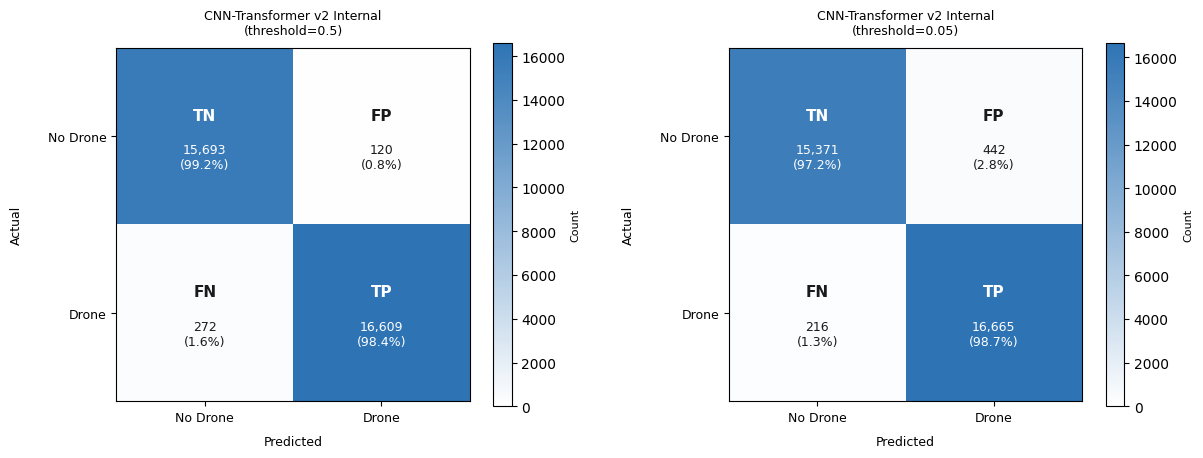

Saved: /content/drive/MyDrive/drone_audio_processed/figures/cnntf_v2_external_cm.png


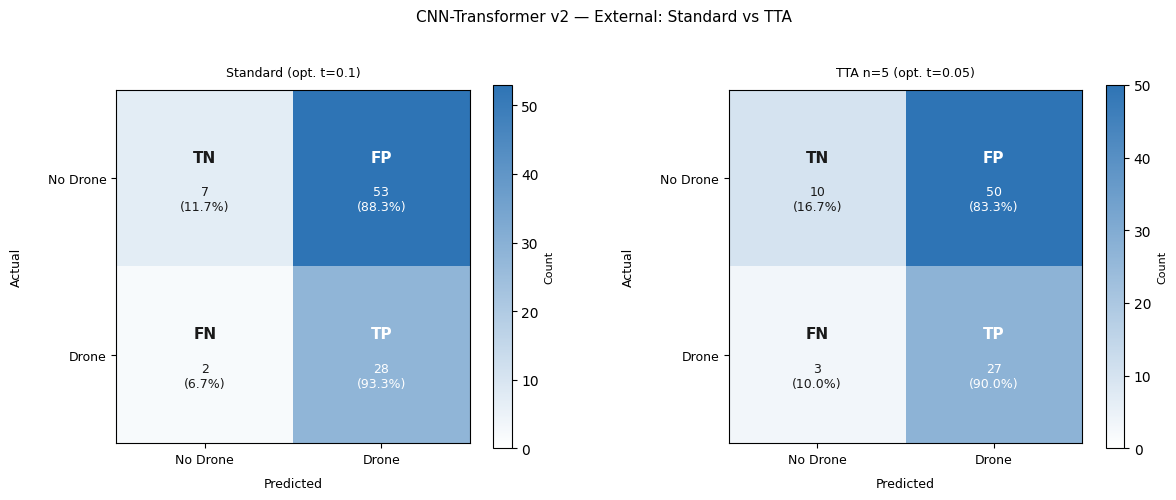

Saved: /content/drive/MyDrive/drone_audio_processed/figures/cnntf_v2_threshold_sweep.png


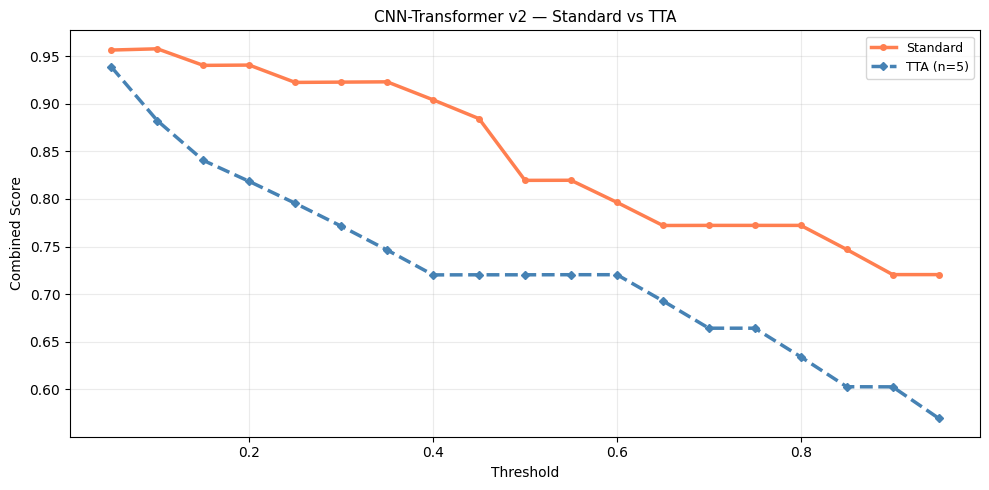

Saved: /content/drive/MyDrive/drone_audio_processed/figures/cnntf_v2_probability_dists.png


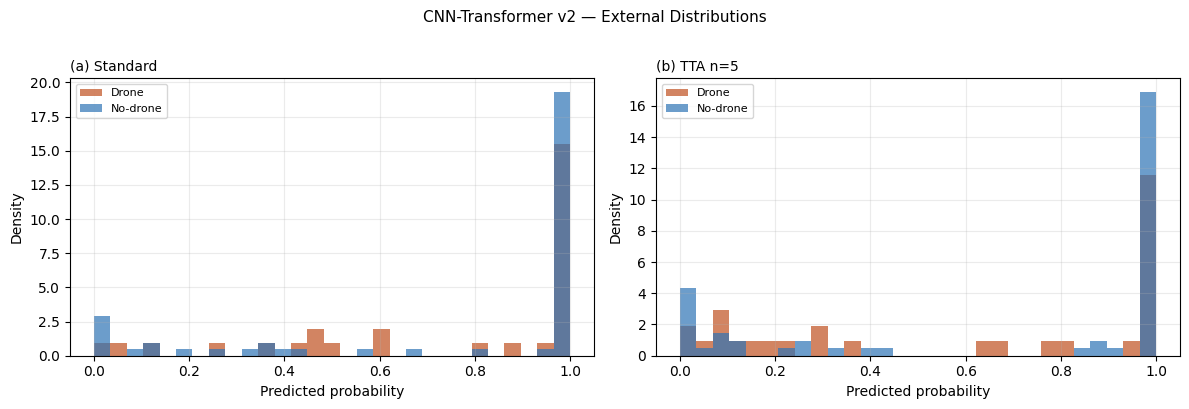

In [ ]:
# Confusion matrices
fig,axes=plt.subplots(1,2,figsize=(13,5));fig.subplots_adjust(wspace=0.55)
plot_cm(confusion_matrix(y_true_eval,(y_prob>=0.5).astype(int)),'CNN-Transformer v2 Internal\n(threshold=0.5)',axes[0])
plot_cm(confusion_matrix(y_true_eval,(y_prob>=0.05).astype(int)),'CNN-Transformer v2 Internal\n(threshold=0.05)',axes[1])
save_fig(fig,'cnntf_v2_internal_cm.png');plt.show()

fig,axes=plt.subplots(1,2,figsize=(13,5));fig.subplots_adjust(wspace=0.55)
plot_cm(confusion_matrix(ext_labels,(ext_probs_std>=float(best_std['threshold'])).astype(int)),
        f'Standard (opt. t={best_std["threshold"]})',axes[0])
plot_cm(confusion_matrix(ext_labels,(ext_probs_tta>=float(best_tta['threshold'])).astype(int)),
        f'TTA n={TTA_N_AUGMENTS} (opt. t={best_tta["threshold"]})',axes[1])
fig.suptitle('CNN-Transformer v2 — External: Standard vs TTA',fontsize=11,y=1.01)
save_fig(fig,'cnntf_v2_external_cm.png');plt.show()

# Threshold sweep plot
fig,ax=plt.subplots(figsize=(10,5))
ax.plot(df_std['threshold'],df_std['combined'],lw=2.5,color='coral',marker='o',ms=4,label='Standard')
ax.plot(df_tta['threshold'],df_tta['combined'],lw=2.5,color='steelblue',marker='D',ms=4,ls='--',label=f'TTA (n={TTA_N_AUGMENTS})')
ax.set_xlabel('Threshold');ax.set_ylabel('Combined Score')
ax.set_title('CNN-Transformer v2 — Standard vs TTA',fontsize=11,fontweight='normal')
ax.legend(fontsize=9);ax.grid(alpha=0.25);plt.tight_layout()
save_fig(fig,'cnntf_v2_threshold_sweep.png');plt.show()

# Probability distributions
fig,axes=plt.subplots(1,2,figsize=(12,4))
bins=np.linspace(0,1,30);dm=ext_labels==1;ndm=ext_labels==0
for ax,probs,title in [(axes[0],ext_probs_std,'(a) Standard'),(axes[1],ext_probs_tta,f'(b) TTA n={TTA_N_AUGMENTS}')]:
    ax.hist(probs[dm],bins=bins,alpha=0.7,color='#C05020',label='Drone',density=True)
    ax.hist(probs[ndm],bins=bins,alpha=0.7,color='#2E74B5',label='No-drone',density=True)
    ax.set_xlabel('Predicted probability');ax.set_ylabel('Density')
    ax.set_title(title,fontsize=10,fontweight='normal',loc='left');ax.legend(fontsize=8);ax.grid(alpha=0.25)
fig.suptitle('CNN-Transformer v2 — External Distributions',fontsize=11,y=1.01)
plt.tight_layout();save_fig(fig,'cnntf_v2_probability_dists.png');plt.show()

In [ ]:
print('\n'+'='*60)
print('CNN-TRANSFORMER v2 — FINAL RESULTS SUMMARY')
print('='*60)
print(f'Parameters         : {n_params:,}')
print(f'Model size         : {model_size:.2f} MB')
print(f'Inference/window   : {ms_v2:.2f} ms')
print(f'Temperature T      : {TEMPERATURE:.4f}')
print(f'Label smoothing    : {LABEL_SMOOTHING}')
print(f'TTA n              : {TTA_N_AUGMENTS}')
print()
print(f'Internal AUC       : {int_auc:.4f}')
print(f'Ext AUC (standard) : {roc_auc_score(ext_labels,ext_probs_std):.4f}')
print(f'Ext AUC (TTA)      : {roc_auc_score(ext_labels,ext_probs_tta):.4f}')
print()
print(f'Standard — best combined: t={best_std["threshold"]}  score={best_std["combined"]}')
print(f'Standard — best ext F1:   {df_std["ext_f1"].max():.4f} at t={df_std.loc[df_std["ext_f1"].idxmax(),"threshold"]}')
print(f'TTA      — best combined: t={best_tta["threshold"]}  score={best_tta["combined"]}')
print(f'TTA      — best ext F1:   {df_tta["ext_f1"].max():.4f} at t={df_tta.loc[df_tta["ext_f1"].idxmax(),"threshold"]}')
print(f'\nFigures saved to: {FIG_DIR}')


CNN-TRANSFORMER v2 — FINAL RESULTS SUMMARY
Parameters         : 895,489
Model size         : 17.47 MB
Inference/window   : 74.48 ms
Temperature T      : 1.0478
Label smoothing    : 0.05
TTA n              : 5

Internal AUC       : 0.9964
Ext AUC (standard) : 0.4444
Ext AUC (TTA)      : 0.4344

Standard — best combined: t=0.1  score=0.9577
Standard — best ext F1:   0.5047 at t=0.2
TTA      — best combined: t=0.05  score=0.9386
TTA      — best ext F1:   0.5047 at t=0.05

Figures saved to: /content/drive/MyDrive/drone_audio_processed/figures
